In [18]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

def get_cmap(cmap_name: str):
    cmap = mpl.colormaps[cmap_name]
    cmap.set_bad("k", 0.5)
    return cmap

inferno = get_cmap("inferno")
seismic = get_cmap("seismic")
coolwarm = get_cmap("coolwarm")

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax
import dLux as dl

print("jax version:", jax.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("amigo version:", amigo.__version__)

cpu
64bit enabled
jax version: 0.8.3
equinox version: 0.13.7
lineax version 0.1.0
zodiax version: 0.5.0
dLux version: 0.15.0
amigo version: 0.0.10


# Loading in data

In [2]:
# Setting data path
from socket import gethostname
from retrain_fns import Tee

print(f"host name: {gethostname()}")

# compile caching
if device.device_kind != "cpu":
    if gethostname().startswith("max-"):
        jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
    else:
        jax.config.update("jax_compilation_cache_dir", "/fred/oz440/max/jax_cache")

    jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
    jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
    jax.config.update("jax_persistent_cache_enable_xla_caches", "xla_gpu_per_fusion_autotune_cache_dir")

    stats = device.memory_stats()
    free = stats["bytes_limit"] - stats["bytes_in_use"]
    print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
    print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
    print(f"Free       : {free / 1024**3:.2f} GB")


if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"
    cache_dir = "/Volumes/research-data/PRJ-PAT/max/data/amigo_cache"
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
    output_path = "/Users/mc/nt_outputs/local_retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
    output_path = "/fred/oz440/max/outputs/retrain"

# cleaning directory of empty folders
for d in os.listdir(output_path):
    this_dir = os.path.join(output_path, d)
    fs = os.listdir(this_dir)
    if len(fs) == 0:
        os.rmdir(this_dir)

# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False

# Quick toggle flags
epochs = 500
n_files_per_filt = 3
one_filt_flag = False
pos1_only = True

print(f"amigo_files_path: {amigo_files_path}")

host name: max-cpuv3-0-16
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.11


In [3]:
from retrain_fns import summarise_files
import importlib

resource_path = importlib.resources.files(amigo).joinpath("data/badpix.npy")

with importlib.resources.as_file(resource_path) as file_path:
    badpix = np.array(np.load(file_path), dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    if file[0].header["EXP_TYPE"] == "NIS_DARK":
        file["BADPIX"].data[25, 74] = 1
    # if file[0].header["PROGRAM"] == "04481" and file[0].header["FILTER"] == "F430M":
    #     file["BADPIX"].data[30, 40] = 1
    return file


## Validation files
Calibrators from other science programs

In [4]:
# from amigo.misc import get_pos
from importlib import resources

badpix = np.array(np.load(resources.files("amigo") / "data" / "badpix.npy"), dtype=float)


def get_pos(file, box=5, return_centroid=False):
    """
    Determine which AMI primary dither position (POS1-POS4) an exposure
    corresponds to, based on centroiding the source in the image data
    and matching it to the nearest known POS pixel location.

    (CRPIX1/CRPIX2 don't work for this since they're fixed by APERNAME
    and don't vary between POS1-4.)

    Parameters
    ----------
    file : astropy.io.fits.HDUList
        An already-opened FITS file, e.g. from fits.open(path).
    box : int
        Half-width of the box around the brightest pixel used for
        the refined centroid.

    Returns
    -------
    pos_label : str
        Closest matching position, e.g. "POS1"
    dist : float
        Pixel distance to that position (sanity check - should be small)
    """
    
    # Reference pixel locations for each dither position (from your image)
    POS_COORDS = {
        "POS1": (46, 40),
        "POS2": (31, 54),
        "POS3": (18, 25),
        "POS4": (59, 24),
    }
    
    data = np.array(file[1].data)
    if data.ndim == 3:
        data = data[-1]  # collapse integrations/frames if needed
    data = np.where(badpix, 0., np.array(data))

    # crude centroid: brightest pixel, refined with a local window
    flat_idx = np.nanargmax(data)
    y0, x0 = np.unravel_index(flat_idx, data.shape)

    y_lo, y_hi = max(0, y0 - box), min(data.shape[0], y0 + box + 1)
    x_lo, x_hi = max(0, x0 - box), min(data.shape[1], x0 + box + 1)
    sub = data[y_lo:y_hi, x_lo:x_hi]

    ys, xs = np.mgrid[y_lo:y_hi, x_lo:x_hi]
    total = np.sum(sub)
    y_c = np.sum(ys * sub) / total
    x_c = np.sum(xs * sub) / total

    target = np.array([x_c, y_c])
    labels = list(POS_COORDS.keys())
    coords = np.array([POS_COORDS[l] for l in labels])

    dists = np.sqrt(np.sum((coords - target) ** 2, axis=1))
    best_idx = int(np.argmin(dists))

    if return_centroid:
        return labels[best_idx], target
    else:
        return labels[best_idx]


def sort_files(files, n):
    files.sort(key=lambda x: (x[0].header["PROGRAM"], x[0].header["FILTER"], x[0].header["PATT_NUM"]), reverse=True)
    filts = ["F480M", "F430M", "F380M"]
    these_files = {}
    for filt in filts:
        x = []
        for file in files:
            if file[0].header["FILTER"] == filt:
                if one_filt_flag and filt != "F480M":
                    continue
                if pos1_only and get_pos(file) != "POS1":
                    continue
                x.append(file)
        these_files[filt] = x[0:n]
    files = [f for sub_f in these_files.values() for f in sub_f]
    return files

## Calibration files
The main training data, including flats.

In [5]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files

calpsf_files = []
# calbin_files = []

print("CAL4481 - Anand Sivaramakrishnan")
program_path = os.path.join(data_dir, "4481/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
calpsf_files += files
calpsf_files = [add_badpix(file) for file in calpsf_files]
calpsf_files = sort_files(calpsf_files, n_files_per_filt)
summarise_files(calpsf_files)

# print()
# print("CAL8330 - Benjamin Pope")
# program_path = os.path.join(data_dir, "8330/calslope/")
# files = get_files(program_path, "nis_calslope")
# calbin_files += files
# calbin_files = [file for file in calbin_files if file[0].header["NGROUPS"] > 3]
# calbin_files = [add_badpix(file) for file in calbin_files]
# calbin_files = sort_files(calbin_files, n_files_per_filt)
# summarise_files(calbin_files)

CAL4481 - Anand Sivaramakrishnan
  program    target filter dither      g/i        date                       PI   CAL
0    4481  HD-41094  F480M    3/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
1    4481  HD-41094  F480M    4/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
2    4481  HD-41094  F480M    5/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
3    4481  HD-41094  F380M    3/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
4    4481  HD-41094  F380M    4/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
5    4481  HD-41094  F380M    5/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
6    4481  HD-41094  F430M    3/5   20/905  05-05-2024  Sivaramakrishnan, Anand  True
7    4481  HD-41094  F430M    4/5   20/905  05-05-2024  Sivaramakrishnan, Anand  True
8    4481  HD-41094  F430M    5/5   20/905  05-05-2024  Sivaramakrishnan, Anand  True


Flats.

# Exposures

In [6]:
from amigo.model_fits import PointFit, FlatFit
from retrain_fns import BinaryFit, DarkFit

# Construct the exposures
calpsf_exposures = [PointFit(file) for file in calpsf_files]
exposures = [*calpsf_exposures]

Finally, let's batch the exposures for training.

# Building model

In [7]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel
from retrain_fns import nn_setup_options

nn_arch = nn_setup_options[0]

# Get the model
model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(**nn_arch),
    read=ReadModel(),
    state=load_dict(amigo_files_path + "/calibration.npy"),
)


Populate from state.

In [61]:
from amigo.fitting import sgd, adam
from zodiax import optimisation as opt
import equinox as eqx
from tqdm.auto import tqdm
import optax

illums = load_dict("files/illums.npy")
ramps = load_dict("files/ramps.npy")
pixel_scale = 6e-06

def one_exp_loss(model, exposure):
    illum = dl.PSF(illums[exposure.key], pixel_scale)
    old_ramp = ramps[exposure.key]
    new_ramp = exposure.model_ramp(illum, model).data
    return -np.nansum(jax.scipy.stats.norm.logpdf(new_ramp, loc=old_ramp))

def loss_fn(params, args):
    print("Compiling loss_fn...")
    model, exposures = args
    model = model.set("nn_weights", params["nn_weights"])
    losses = [one_exp_loss(model, exp) for exp in exposures]
    return np.array(losses).mean()

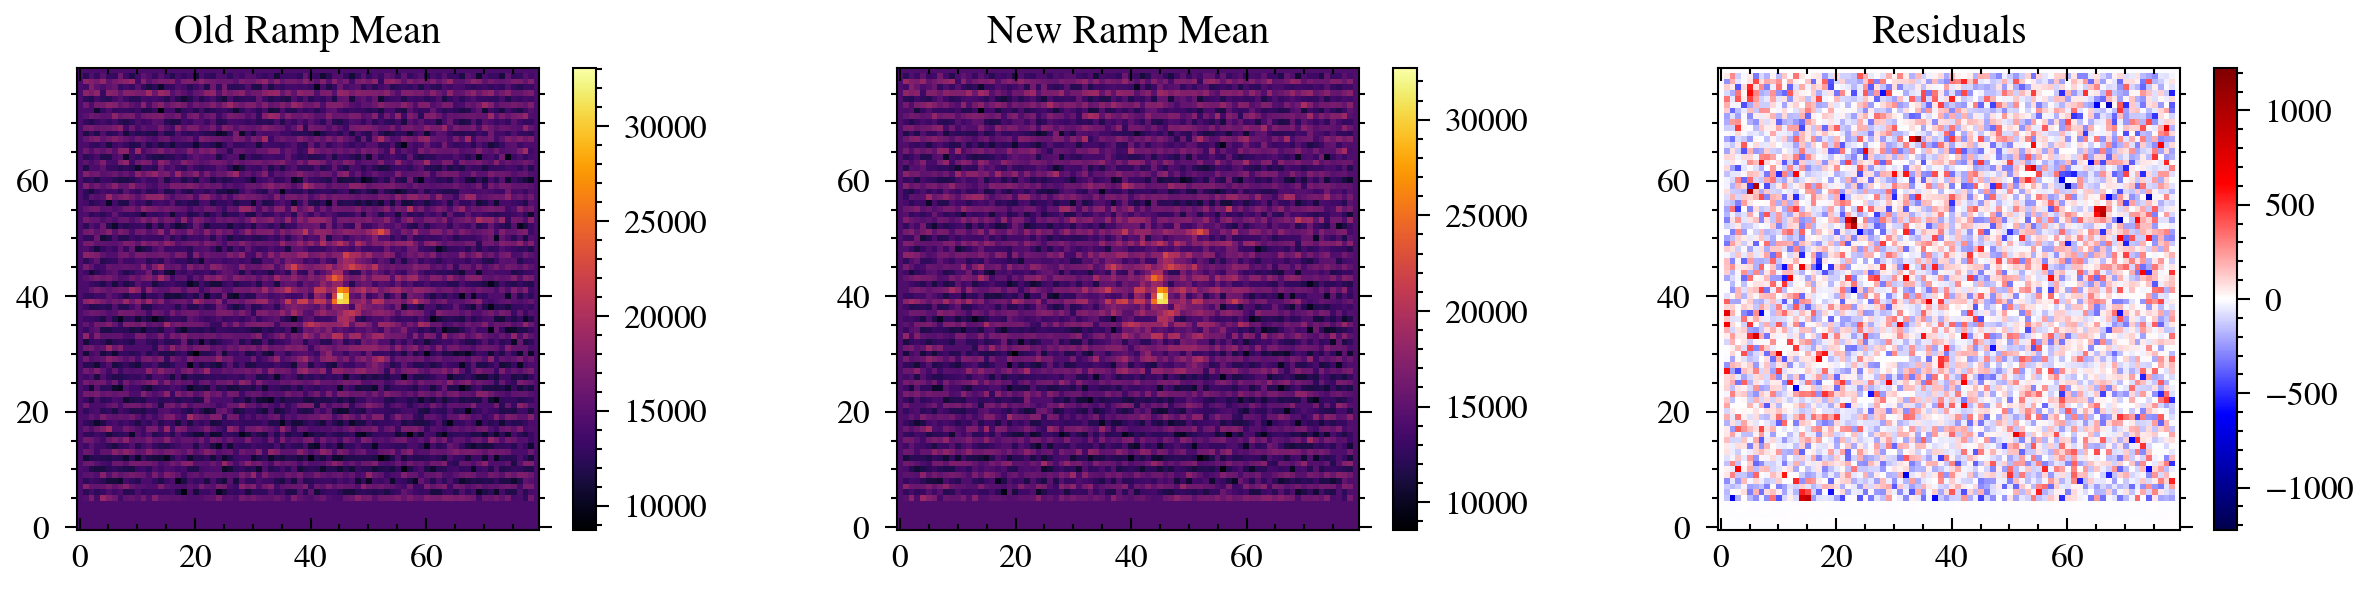

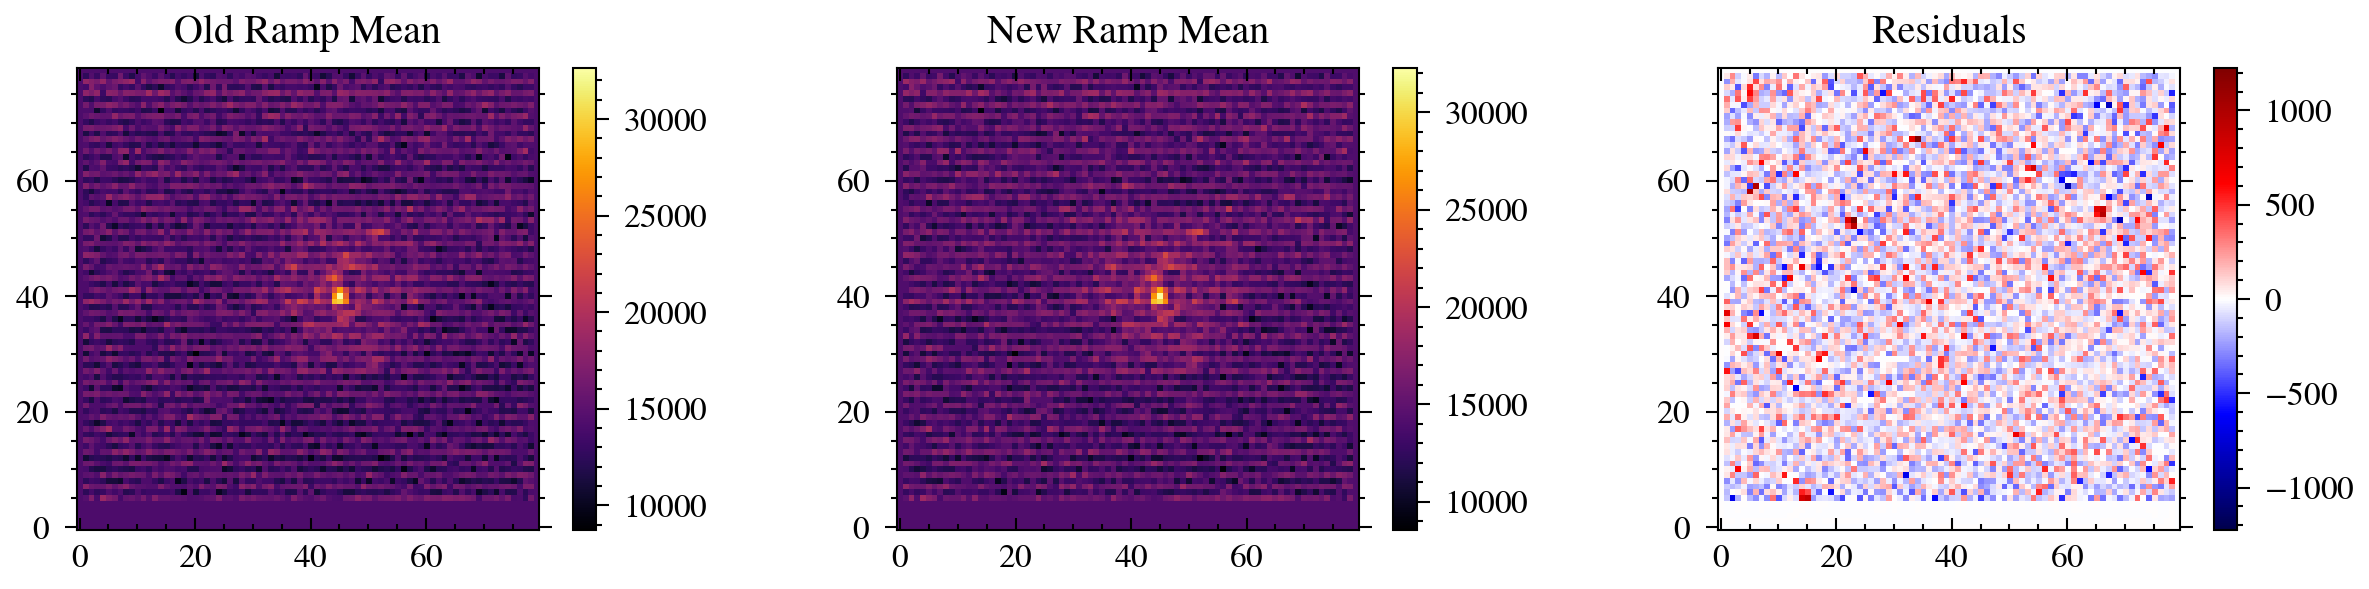

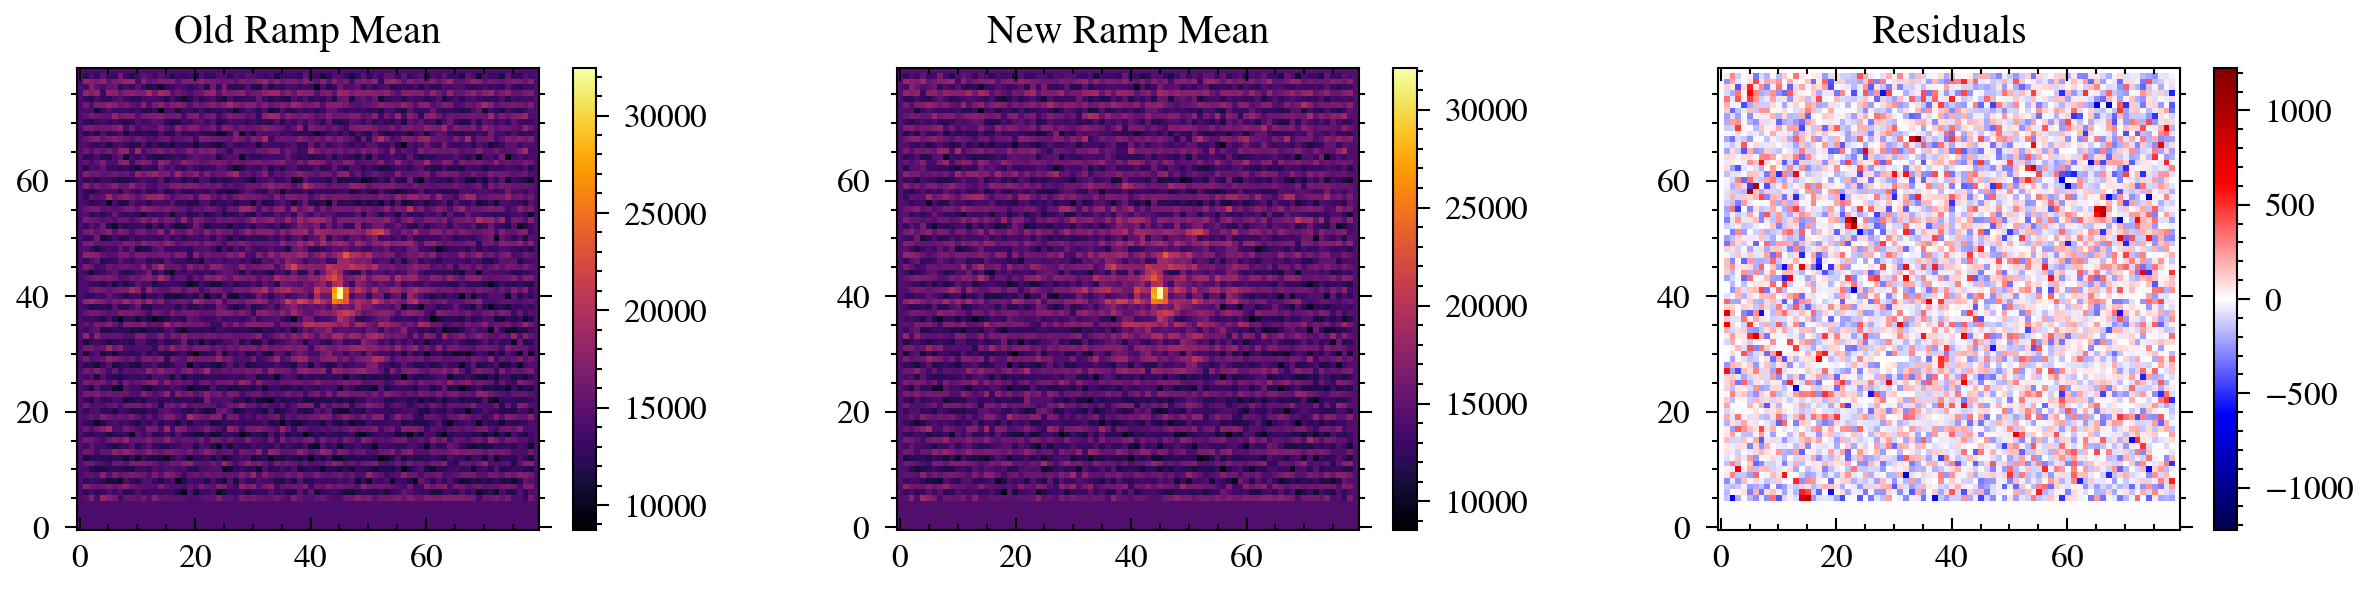

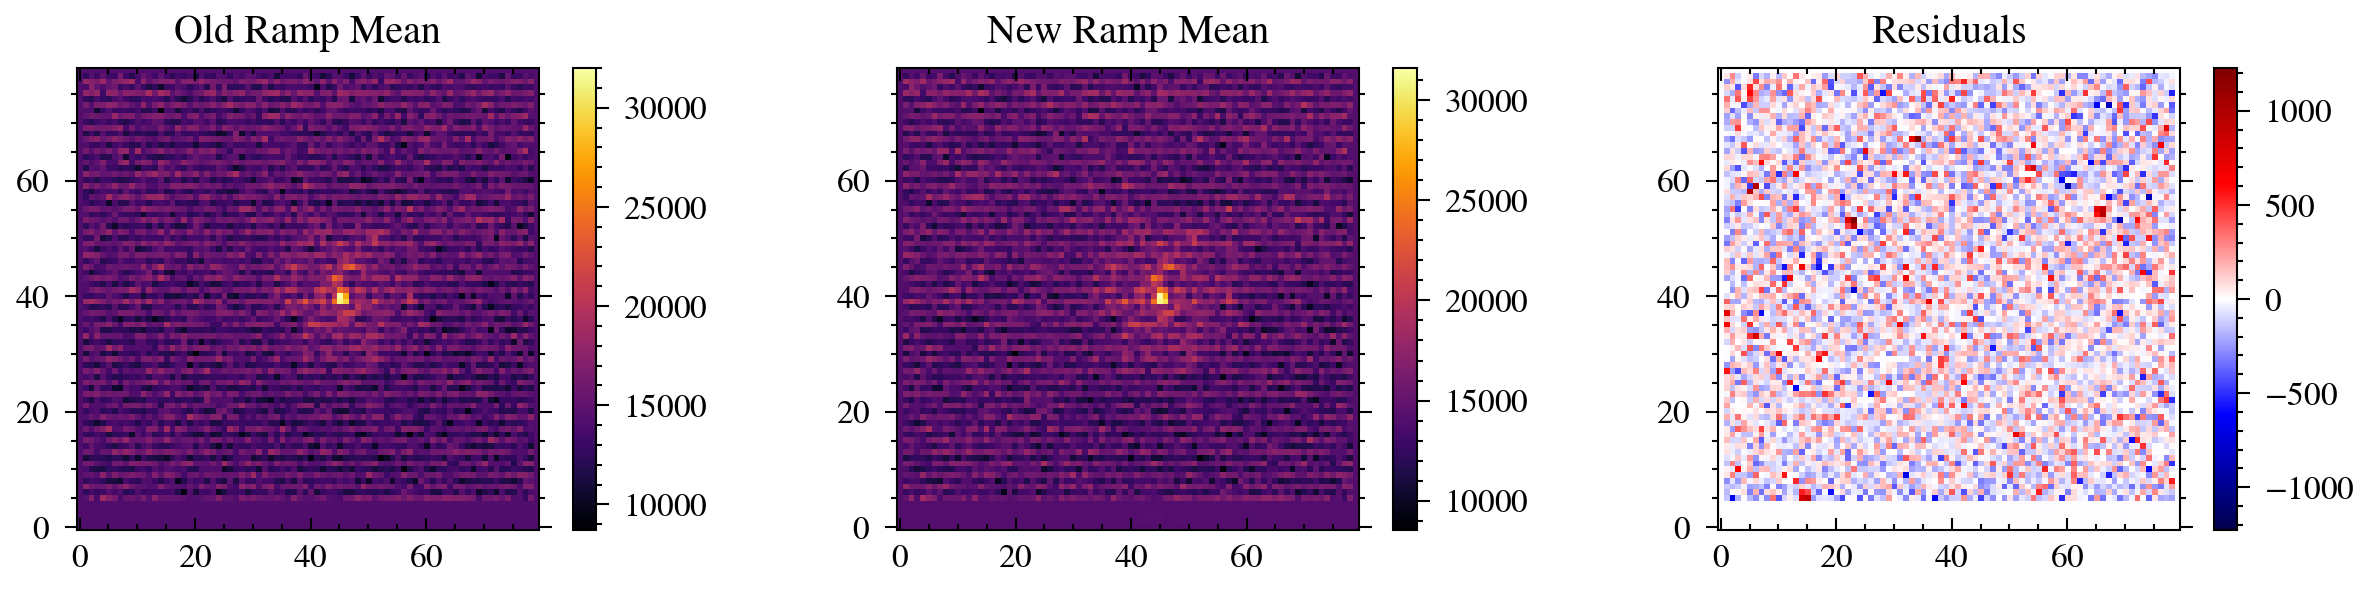

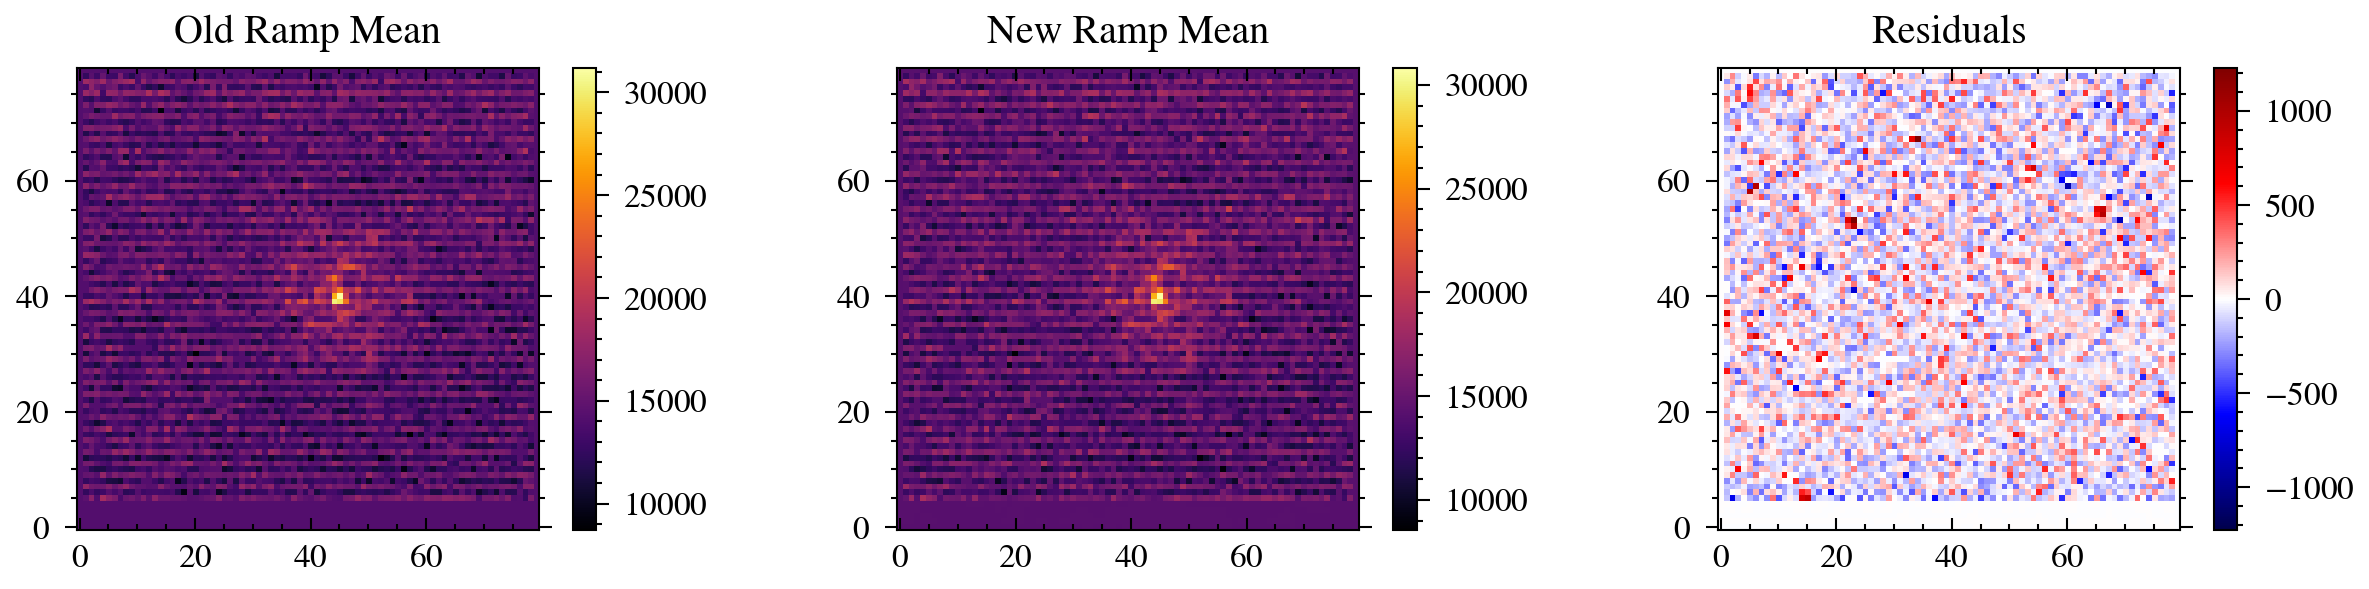

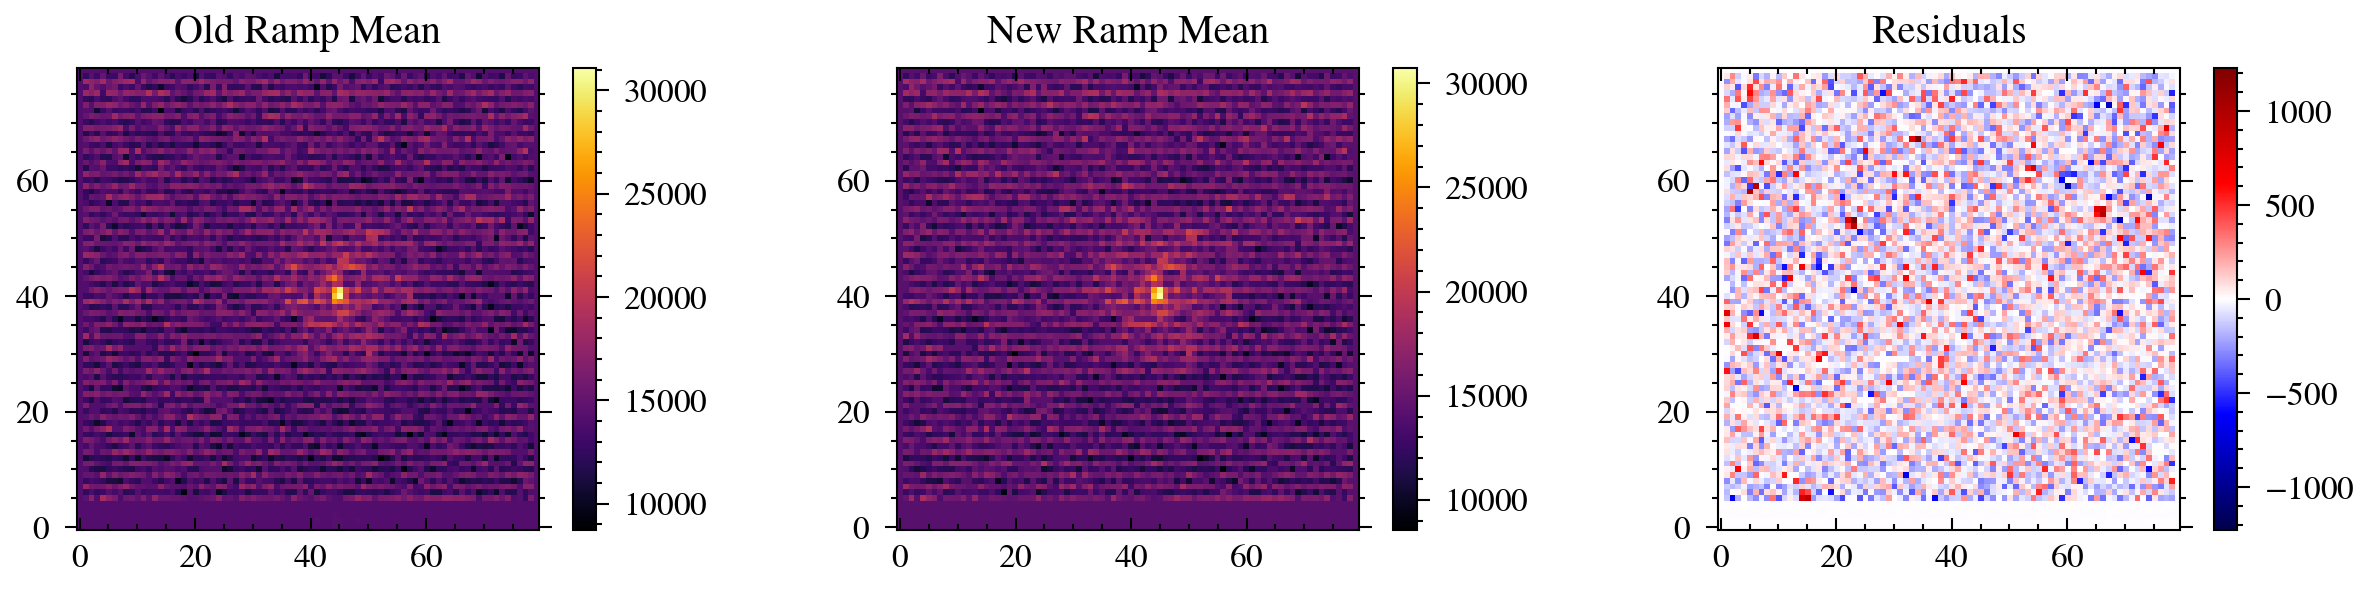

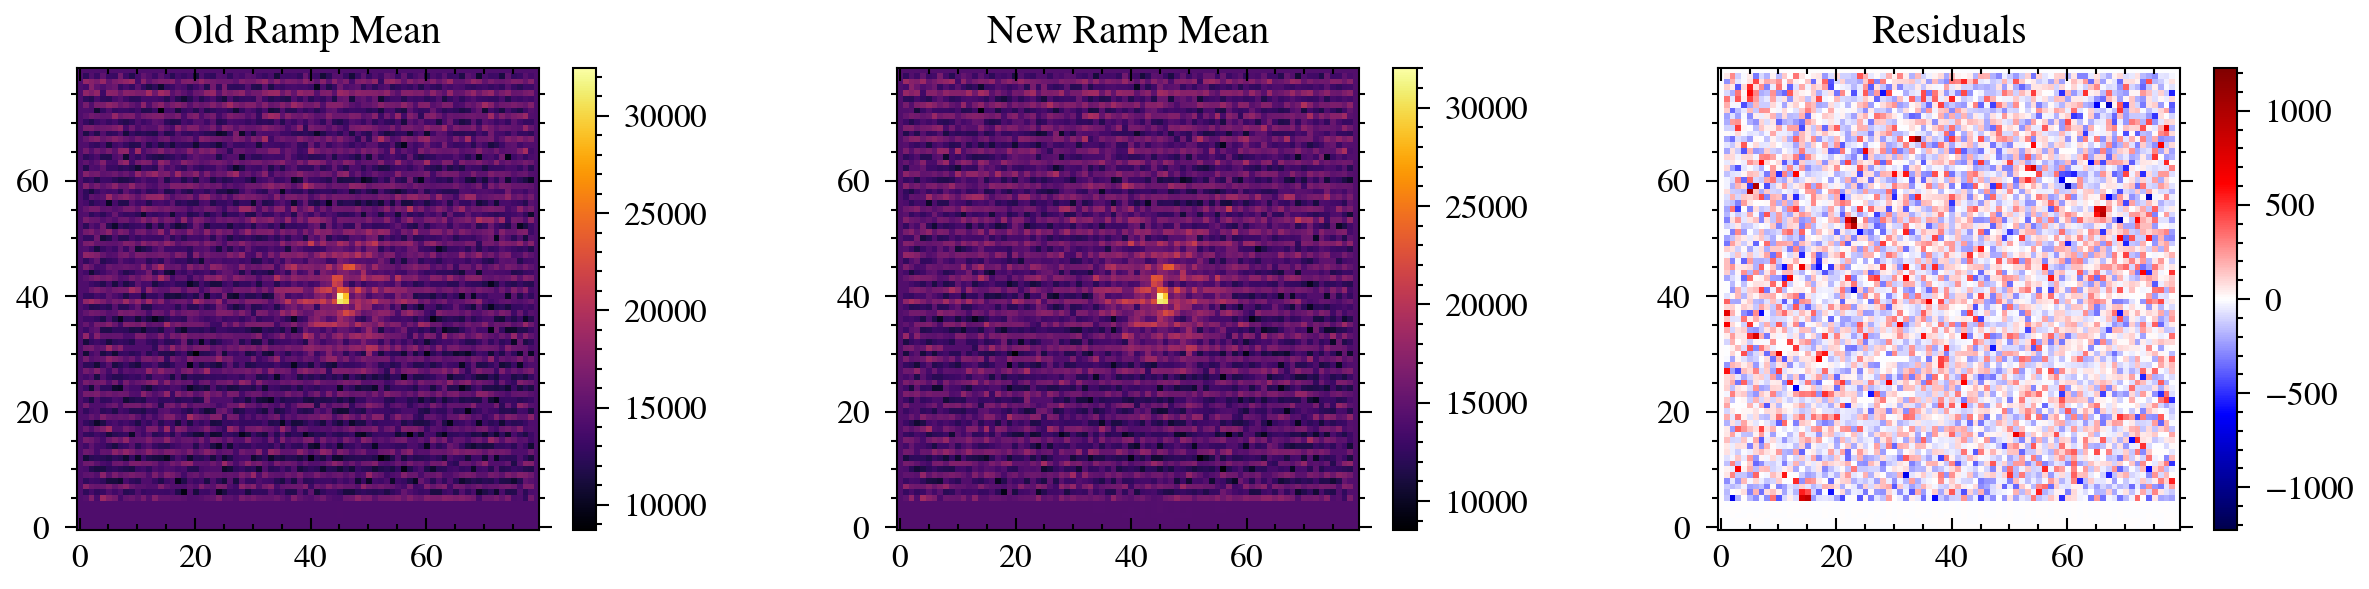

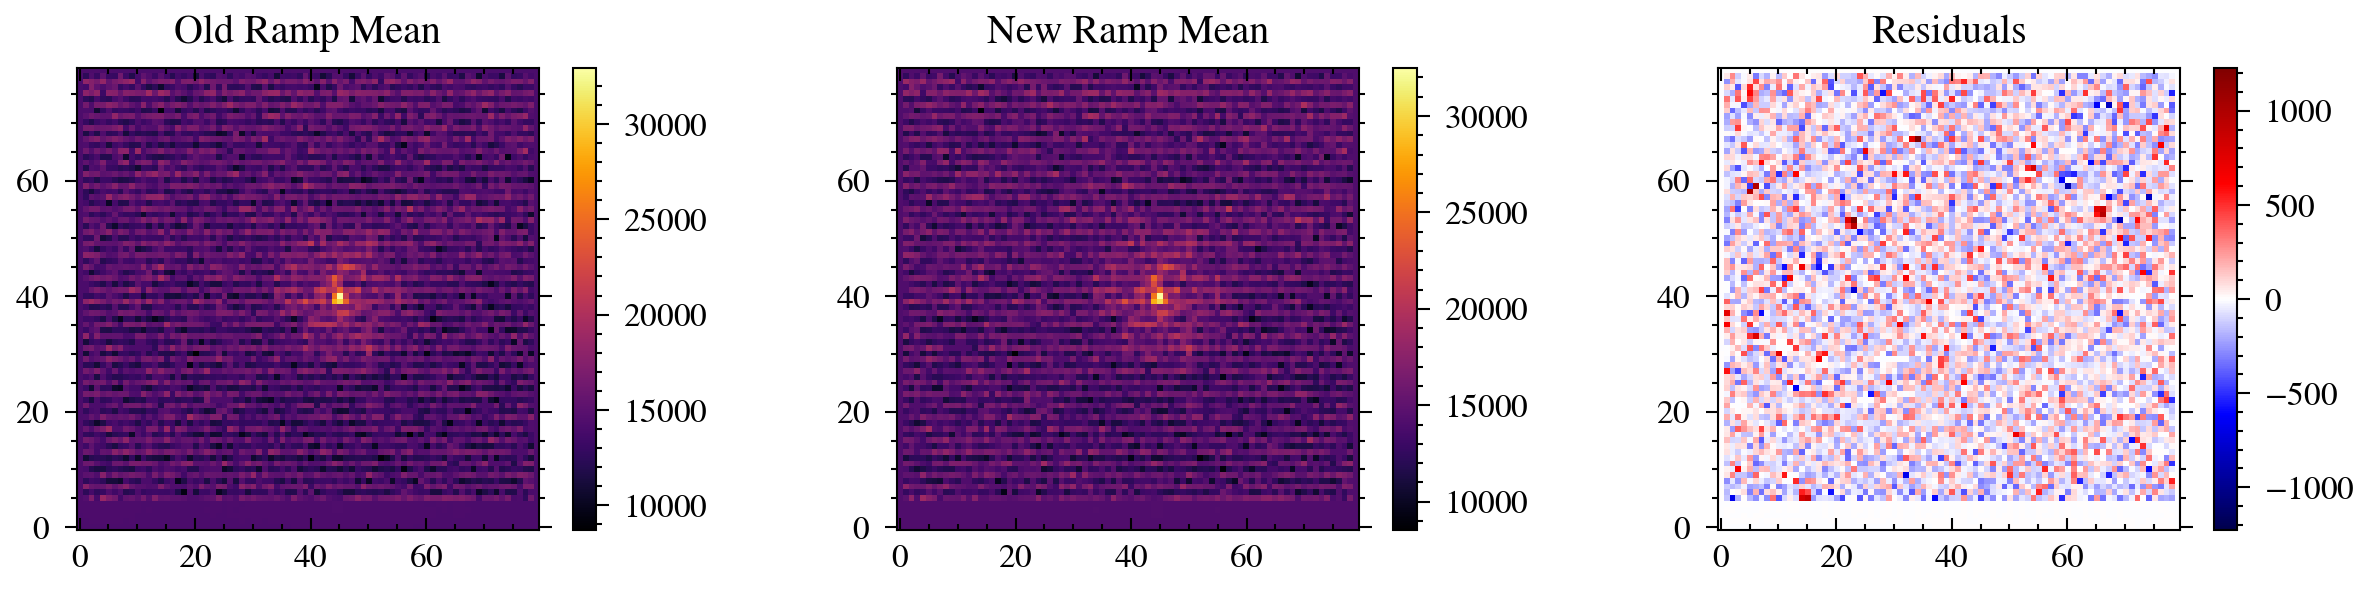

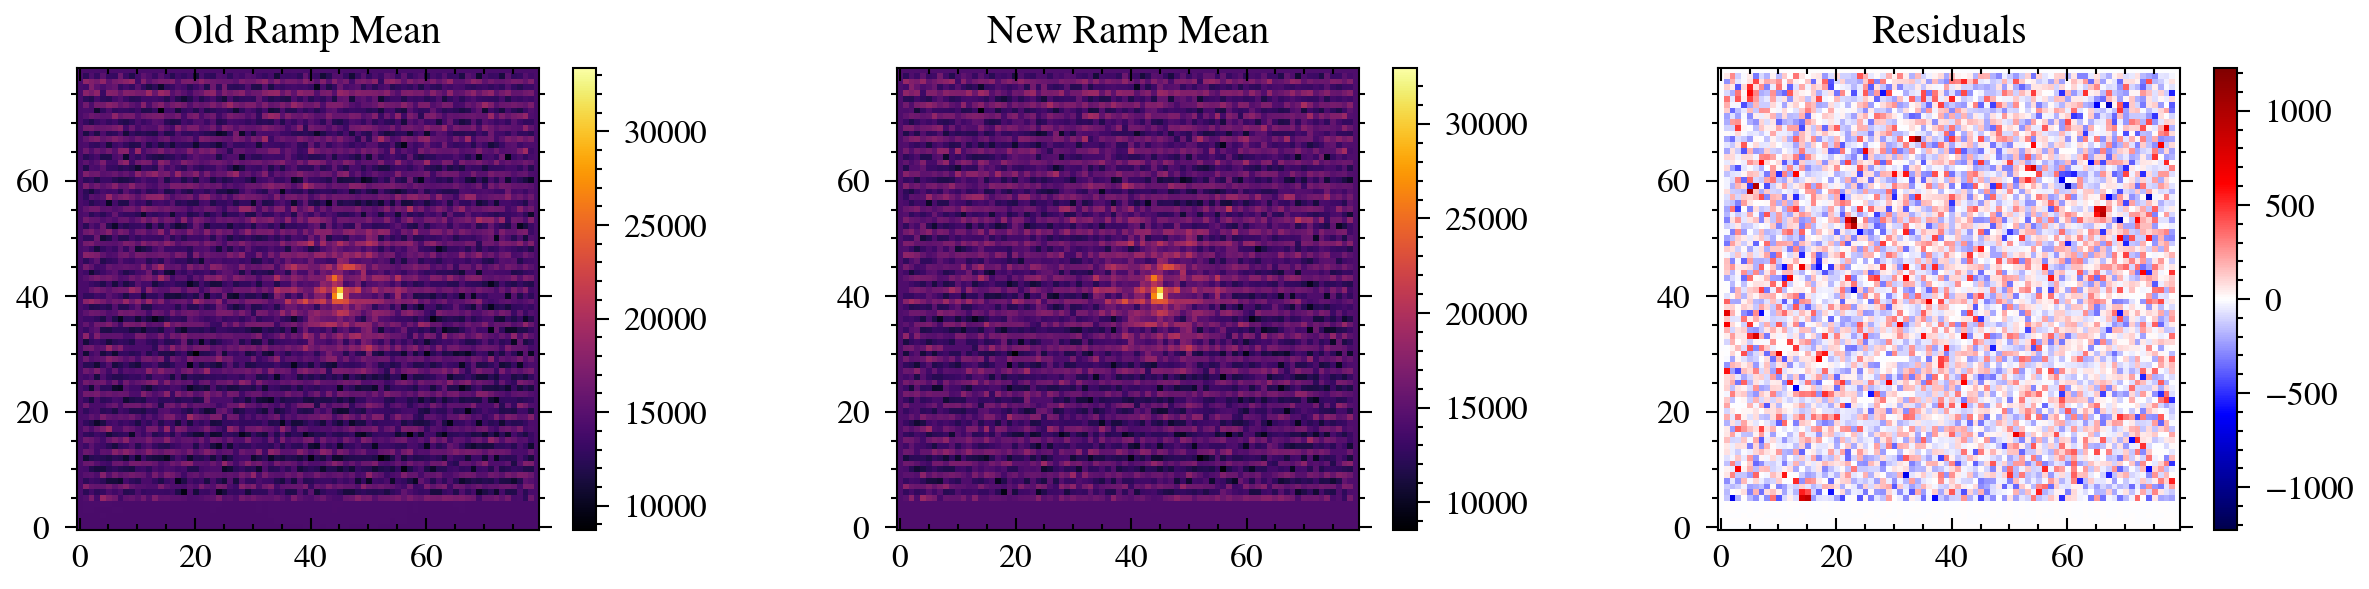

In [101]:
for exposure in exposures:
    illum = dl.PSF(illums[exposure.key], pixel_scale)
    old_ramp = ramps[exposure.key]
    new_ramp = exposure.model_ramp(illum, model).data

    fig, ax = plt.subplots(1, 3, figsize=(10, 2))

    im = ax[0].imshow(old_ramp.mean(0), inferno)
    fig.colorbar(im)
    ax[0].set(
        title="Old Ramp Mean",
    )
    
    im = ax[1].imshow(new_ramp.mean(0), inferno)
    fig.colorbar(im)
    ax[1].set(
        title="New Ramp Mean",
    )
    
    im = ax[2].imshow((old_ramp - new_ramp).mean(0), seismic, norm=mpl.colors.CenteredNorm())
    fig.colorbar(im)
    ax[2].set(
        title="Residuals",
    )
    
    plt.show()
    


In [74]:
epochs = 10        

# JIT and grad transform the loss function
loss_grad_fn = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn))

# Define our optimisers that we map to each parameter
optimisers = {
    "nn_weights": sgd(1e0, 0),
}

params = {"nn_weights": model.nn_weights}

# Now we map the optimisers to the parameters and get the initial state
optim, state = opt.map_optimisers(params, optimisers)

# Bundle up the arguments
args = (model, exposures)
# init_loss = loss_fn(params, args)

# Now we can run a simple optimisation loop
losses = []
progress_bar = tqdm(range(epochs), desc=f"Loss: ")

for step in progress_bar:
    loss, grads = loss_grad_fn(params, args)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    
    losses.append(loss)
    progress_bar.set_description(f"Loss: {loss:.4e}")
losses = np.array(losses)

Loss:   0%|          | 0/10 [00:00<?, ?it/s]

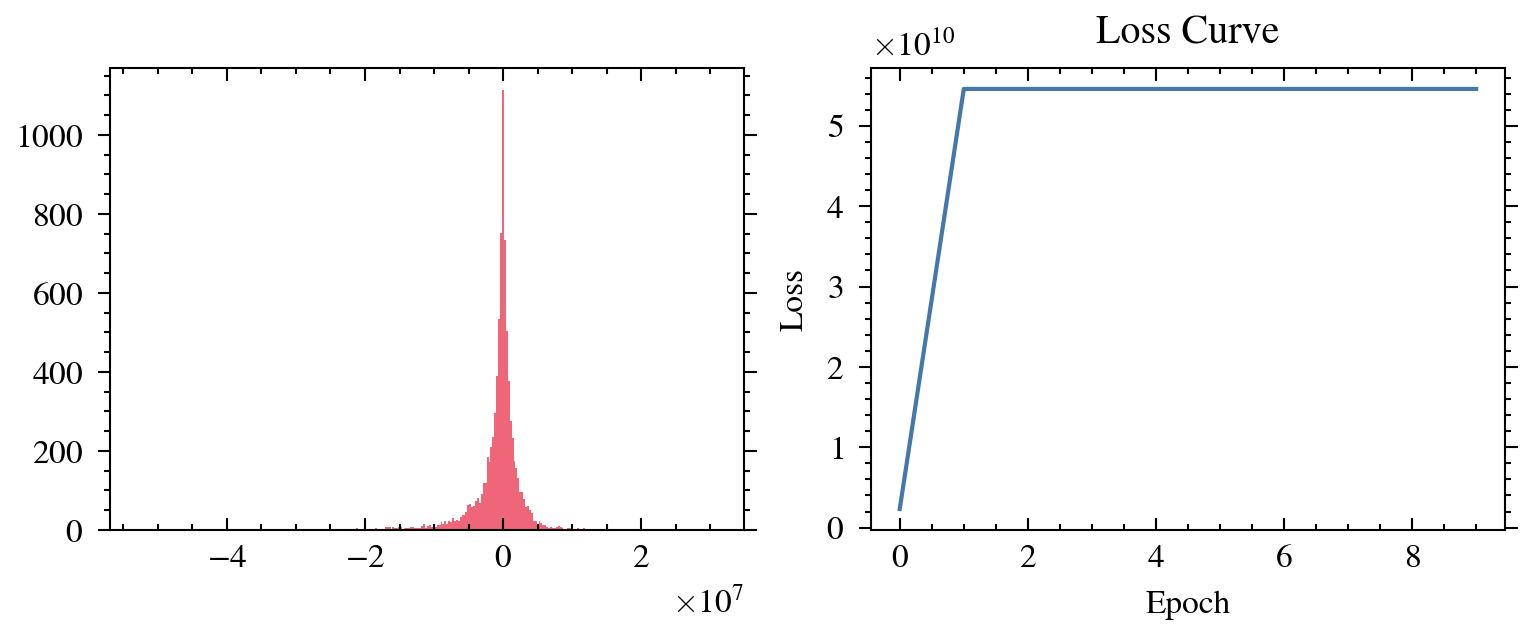

In [89]:
fig, ax = plt.subplots(1, 2, figsize=(6, 2))

ax[0].hist(model.nn_weights.ravel(), bins=300)
ax[0].hist(params["nn_weights"].ravel(), bins=300)

ax[1].plot(losses)
ax[1].set(
    title="Loss Curve",
    xlabel="Epoch",
    ylabel="Loss",
)
plt.show()